# Introduction


**File:** Notebook_mu_vs_I.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 16.03.2026
\
**Problem:** Find how the parameter $\mu$ changes the expected current of a loop.

This Jupyter notebook is used for showing how $\mu$ changes the persistent current $I$ in micrometer scale gold loops which solve the BVP of the nonlinear Schrödinger equation. 

For our observed approximate solution to the nonlinear Schrödinger equation
\begin{equation}
\psi(x) = e^{i M_{j} x} \left( a e^{i k_{j} x} + b e^{- i k_{j} x} \right),
\end{equation}
we know that $\psi(0) = \psi(2\pi R)$ when 
\begin{equation}
\psi^\prime(0) = i M_{j} + k_j \left( \frac{e^{- 2 i M_{j}\pi R} - \cos\left( 2\pi k_{j} R \right)}{\sin\left(2\pi k_{j} R\right)}\right),
\end{equation}

where $k_{j}\left(\mu, R, B, k_0, \psi^\prime(0) \right)$ and $M_{j}\left(\mu, R, B, k_0, \psi^\prime(0) \right)$ are given by our previously solved model. Since the equations for $k_j$ and $M_j$ of our model are dependent on $\psi^\prime(0)$, we have obtained the values of $\psi^\prime(0)$ which solve this BVP equation with a numerical root finding algorithm. From this, we can calculate the current for each loop,
\begin{equation}
I_j =\left|a_j\right|^2 - \left|b_j\right|^2 = - \left| \psi(0) \right|^2 \frac{\sin\left(2 \pi M_j R_j\right)}{\sin\left(2 \pi k_j R_j\right)}.
\end{equation}
However, $k_{j}\left(\mu, R, B, k_0, \psi^\prime(0) \right)$ and $M_{j}\left(\mu, R, B, k_0, \psi^\prime(0) \right)$ differ from their linear values, and we wish to see how this change in $k_j$ and $M_j$ impacts the average value of $\mu$.


# Load Grids

We will start, as typical, with our libraries.

In [1]:
# my library
import eelib
from eelib import pi, B_max, phi0inv, R_max
from eelib import clean_table, clean_table_MC

import numpy as np
import pickle
import pandas as pd

# machine learning
from sklearn.linear_model import LinearRegression

# plotting
import matplotlib.pyplot as plt
import seaborn as sns #statistical data visualization


And loading our data from previous runs of our bvp_grid code.

In [2]:
grid_a = []
for i in range(20):
    filename = f'grid_{i}'

    # loading script; be careful of python version
    file = open(filename, 'rb')    
    grid_a.append(pickle.load(file))
    file.close()

Now to check our objects.

In [3]:
print(grid_a)

[Monte Carlo object to measure current:
mu has points from 1.162003149250373e-10 to 1.162003149250373e-10.
dk has points from 0.10144953984566536 to 0.8975618370208304.
B has points from 0.11069720894701807 to 0.9993352694851243.
R has points from 0.5702694588137152 to 0.9992162606283497.
A has points from 1.0 to 1.0.
k0 has points from 12000000000.0 to 12000000000.0.
Number of points: 1000, Monte Carlo object to measure current:
mu has points from 1.9824325383061886e-10 to 1.9824325383061886e-10.
dk has points from 0.1020501295339102 to 0.8993006833005913.
B has points from 0.11003655409359814 to 0.9994556861863311.
R has points from 0.5700018058787951 to 0.9999482921415169.
A has points from 1.0 to 1.0.
k0 has points from 12000000000.0 to 12000000000.0.
Number of points: 1000, Monte Carlo object to measure current:
mu has points from 2.768407372706797e-10 to 2.768407372706797e-10.
dk has points from 0.10172192222794268 to 0.8995607584012655.
B has points from 0.11031103068752625 to 0

# Make Tables

First, load the tables from my objects into pandas dataframes. The data has been saved in my objects in a form of a list of dictionaries, designed to easily form a pandas dataframe with a simple function call.

Tables below can be commented or uncommented as needed.

In [4]:
tbl = []
for i in range(20):
    tbl.append(pd.DataFrame(grid_a[i].derivs))
#tbl003 = pd.DataFrame(gridl_3.derivs)

I will also need to get the values of my parameters for grid analyses, so that I can easily select all points with the same value of the given parameter. We also will pull $k  = k_{Fermi, Au}$ and $A = \psi(0) = 1$.

Lets now check to see that the solutions we are given produce the correct final value of $\psi(2\pi R)$ according to our models for $k_j$ and $M_j$. The values for "New End" and "Exact End" on our table are the values for $\psi(2\pi R)$ for our nonlinear and linear solutions, respectively. The have been calculated from our model of $\psi(x)$, for said solution. They have not been calculated with the IVP solver, as the error would make such results meaningless. 

In [5]:
for i in range(20):
    print(f"(Table {i}) Maximum error with ee interaction:   ", np.max(np.abs(tbl[i]["New End"].to_numpy()-(1.0+0.0j))))
    print(f"(Table {i}) Maximum error without ee interaction:", np.max(np.abs(tbl[i]["Exact End"].to_numpy()-(1.0+0.0j))))
#print("(Table 3) Maximum error with ee interaction:   ", np.max(np.abs(tbl003["New End"].to_numpy()-(1.0+0.0j))))
#print("(Table 3) Maximum error without ee interaction:", np.max(np.abs(tbl003["Exact End"].to_numpy()-(1.0+0.0j))))

(Table 0) Maximum error with ee interaction:    0.009201889327750455
(Table 0) Maximum error without ee interaction: 1.6441066788433165e-09
(Table 1) Maximum error with ee interaction:    0.009825077932179632
(Table 1) Maximum error without ee interaction: 1.0086262181222776e-09
(Table 2) Maximum error with ee interaction:    0.00997375545892799
(Table 2) Maximum error without ee interaction: 1.0729569597862268e-08
(Table 3) Maximum error with ee interaction:    0.009844825189923268
(Table 3) Maximum error without ee interaction: 1.19613120229654e-09
(Table 4) Maximum error with ee interaction:    0.009902852556352187
(Table 4) Maximum error without ee interaction: 3.876659911011255e-09
(Table 5) Maximum error with ee interaction:    0.009933389797633127
(Table 5) Maximum error without ee interaction: 7.270355217245944e-09
(Table 6) Maximum error with ee interaction:    0.009840206844655173
(Table 6) Maximum error without ee interaction: 1.5044309112022064e-09
(Table 7) Maximum error w

Now to dump the unneeded data from the tables.

From previous analysis, I know that "I v2" is the best version of my calculation for the current of the nonlinear solution. This value is equal to the "I v3" current, which is calculated at our initial position, using the full equation for $I_j$,
\begin{equation}
I_j = \frac{1}{2 k_0 i}\left( \overline{\psi_j} \frac{d}{dx} \psi_j -\psi_j \overline{\frac{d}{dx} \psi_j} -i \frac{2 B \pi R_j}{\Phi_0} \overline{\psi_j}  \psi_j  \right),
\end{equation}
with our known $\psi(0)$ and $\psi^\prime(0)$ values. We will thus remove "I v1" and "I v3" from our table. 

$k$ and $A$ are unnecessary as they are always identical. After I have checked "Exact End" and "New End", they are no longer required. That leaves 4 independent variables and 11 dependent variables. Note that here there is still unnecessary data, but at this point I don't know it is unnecessary.

In [6]:
tbl_2 = []
for i in range(20):
    tbl_2.append(tbl[i][["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v3', 'effective mu']])
#tbl013 = tbl003[["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v2', 'effective mu']]

The next step is to clear the table of all the unneeded high energy solutions, as I need to only keep the lowest energy solution for every set of parameters. The functions to clear out this data are in the table_scripts.py file in my library.

In [7]:
tbl_3 = []
for i in range(20):
    tbl_3.append(clean_table_MC(tbl_2[i]))
#tbl023 = clean_table(tbl013)

And a test of just one of these dataframes.

In [8]:
tbl_3[1].head()

,R,B,dk,mu,dpsi0,a0,b0,A max 0,I0,dpsi,a,b,A max new,I v3,effective mu
0,0.685016,0.633618,0.698643,1.982433e-10,4.900411e+10+1.054338e+ 10j,0.939116-2.041778j,0.060884+2.041778j,4.290084,0.878232,4.648403e+10+1.004095e+ 10j,0.918182-1.936778j,0.081818+1.936778j,4.081907,0.836364,3.303121e-09
1,0.725189,0.167388,0.389021,1.982433e-10,3.236097e+10+1.568827e+ 10j,1.153618-1.348352j,-0.153618+1.348352j,3.131585,1.307235,3.153154e+10+1.534149e+ 10j,1.139169-1.313793j,-0.139169+1.313793j,3.060039,1.278337,1.856318e-09
2,0.644156,0.642542,0.318470,1.982433e-10,1.015212e+11-4.554655e+ 10j,-1.397918-4.229996j,2.397918+4.229996j,9.317395,-3.795836,7.574076e+10-3.416696e+ 10j,-0.923775-3.155823j,1.923775+3.155823j,6.984209,-2.847550,9.670144e-09
3,0.730298,0.854007,0.565302,1.982433e-10,1.422854e+10+1.676916e+ 08j,0.506730-0.592842j,0.493270+0.592842j,1.551113,0.013461,1.417566e+10+1.674188e+ 08j,0.506719-0.590639j,0.493281+0.590639j,1.547747,0.013438,4.748960e-10
4,0.788551,0.366027,0.377934,1.982433e-10,8.088236e+08+1.204244e+ 10j,1.001642-0.033700j,-0.001642+0.033700j,1.035949,1.003283,7.819170e+08+1.203940e+ 10j,1.001515-0.032579j,-0.001515+0.032579j,1.034659,1.003030,2.122233e-10


I want to try to do the same thing with a dataset which occupies all of my expected parameter range.

From the plot above, the decreasing current with increasing $\mu$ remains. A $dk$ shape also appears, but we already know that it is from the oscillation structure, not large-scale structure.

In [9]:
mu_arr = []
I_max = []
I_min = []
I0_min = []
I0_max = []
for tt in tbl_3:
    mu_arr.append(tt["mu"][0])
    I_max.append(np.max(tt["I v3"].to_numpy()))
    I_min.append(np.min(tt["I v3"].to_numpy()))
    I0_max.append(np.max(tt["I0"].to_numpy()))
    I0_min.append(np.min(tt["I0"].to_numpy()))

In [ ]:
# Redefine my table as a separate object, and not a slice
#vals1 = tbl023[["R", "B", "dk", "mu", "I0", "I v2"]].to_numpy()
# All the values are real, so there is no issue of casting the numbers as complex
#tbl043 = pd.DataFrame(vals1, columns=["R", "B", "dk", "\u03BC", "I0", "I\u03BC"])

In [ ]:
#gs = R2_arr.shape[0] # Size of our grid
# When I labeled these shapes, the second R, B, etc. arrays came from the third table, which was the fourth dataset. 
# This naming convention comes from my BVP to end notebook.
# While I could fix the naming convention now, it seems unnecessary. I have fixed this for the BVP_k_M notebook.

In order to properly extract the pattern, we need to find the minimum and maximum current $I_{\mu}$ for a given $\mu$ value. 

This analysis is done on a grid so that I can select $\mu$ values and find the minimum and maximum current of each value of $\mu$. To do this with the proper Monte Carlo analysis, I would need to choose random $\mu$ values, then random values of the other parameters for a number of points for each such value of $\mu$. I could set this up, but so far have not added this variant.

In [ ]:
#I_min = np.zeros(gs)
#I_max = np.zeros(gs)
#for i, mun in enumerate(mu2_arr):
#    tbl_n = tbl043[(tbl043["\u03BC"]==mun)]
#    I_min[i] = np.min(tbl_n["I\u03BC"].to_numpy())
#    I_max[i] = np.max(tbl_n["I\u03BC"].to_numpy())

In [10]:
np.min(I0_min), np.max(I0_max)

(-21739.40634393692, 16609.125012472272)

In [11]:
mu_np = np.array(mu_arr)
Imn_np = np.array(I_min)
Imx_np = np.array(I_max)

And now to plot our maxima and minima.

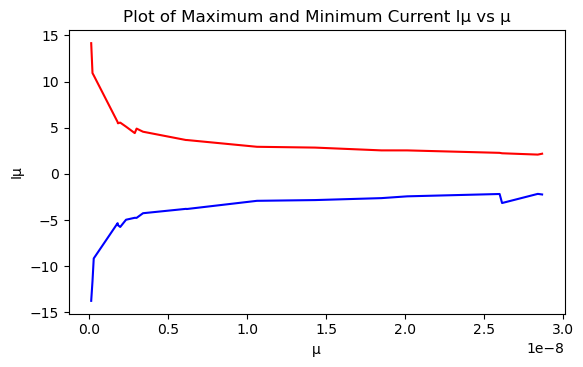

In [12]:
fig, ax = plt.subplots()
plt.title(f"Plot of Maximum and Minimum Current I\u03BC vs \u03BC")
ax.set_ylabel('I\u03BC')
ax.set_xlabel("\u03BC")

x = mu_np
y1 = Imn_np
y2 = Imx_np

ax.plot(x, y1, color = "blue")
ax.plot(x, y2, color = "red")

ax.set_box_aspect(2.0/3.5)


plt.show()


The next plot is our log-log plot: $\ln\left|I_{max}\right|$ and $\ln\left|I_{min}\right|$ vs $\ln\left(\mu\right)$. If this dependence follows a power-law, the graphs will be straight lines.

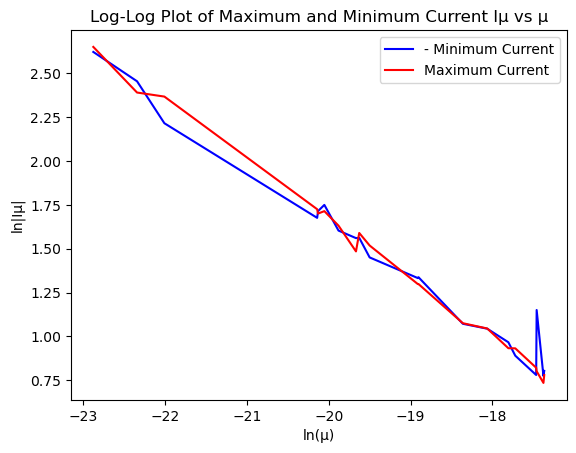

In [13]:
fig, ax = plt.subplots()
plt.title(f"Log-Log Plot of Maximum and Minimum Current I\u03BC vs \u03BC")
ax.set_ylabel('ln|I\u03BC|')
ax.set_xlabel("ln(\u03BC)")

x = mu_np
y1 = Imn_np
y2 = Imx_np

# Plot logrithm to visually inspect power-law dependence
ax.plot(np.log(x), np.log(np.abs(y1)), color = "blue", label = "- Minimum Current")
ax.plot(np.log(x), np.log(y2), color = 'red', label = "Maximum Current")

plt.legend()

plt.show()

They indeed look straight, and fall on top of each other, as would be expected if there is no preferred sign of $I$. Lets now fit the $\mu$ dependence to a power law. I will apply linear regression to $\ln\left(I_{max}\right)$ first, then $\ln\left(-I_{min}\right)$. I will use the average values for the power of $\mu$ and its coefficient as my model.

In [14]:
# Linear regression

X = np.log(mu_np) # Power laws are straight lines on log-log plots.
X=X.reshape(-1, 1)
y = np.log(np.abs(Imx_np)) # Power laws are straight lines on log-log plots.

reg = LinearRegression().fit(X, y)

slope_max=reg.coef_[0]
intercept_max=reg.intercept_

r = reg.score(X, y)

print("For the linear regression of ln(I_max) vs ln(\u03BC)")
print(f"Fitted power of \u03BC:      {slope_max}")
print(f"ln of coefficient of \u03BC: {intercept_max}")
print("Convergence Statistic:  ", r) 

For the linear regression of ln(I_max) vs ln(μ)
Fitted power of μ:      -0.3362852587922337
ln of coefficient of μ: -5.059754192330836
Convergence Statistic:   0.9967273449628058


In [15]:
# Regression

r = 1.1    # for finding the minimum r value

X = np.log(mu_np) # Power laws are straight lines on log-log plots.
X=X.reshape(-1, 1)
y = np.log(np.abs(Imn_np)) # Power laws are straight lines on log-log plots.

reg = LinearRegression().fit(X, y)

slope_min=reg.coef_[0]
intercept_min=reg.intercept_

r = reg.score(X, y)

print("For the linear regression of ln(-I_min) vs ln(\u03BC)")
print(f"Fitted power of \u03BC:      {slope_min}")
print(f"ln of coefficient of \u03BC: {intercept_min}")
print("Convergence Statistic:  ", r) 

For the linear regression of ln(-I_min) vs ln(μ)
Fitted power of μ:      -0.31714721885522806
ln of coefficient of μ: -4.677308890469586
Convergence Statistic:   0.9772348200567238


In [16]:
slope = np.average([slope_max, slope_min])
intercept = np.average([intercept_max, intercept_min])
print("Average Slope:     ", slope)
print("Average Intercept: ", intercept)
print("Coefficent of \u03BC: ", np.exp(intercept))

Average Slope:      -0.3267162388237309
Average Intercept:  -4.868531541400211
Coefficent of μ:  0.007684641584502864


Now I will add this model to both the log-log and the linear-linear plots. 

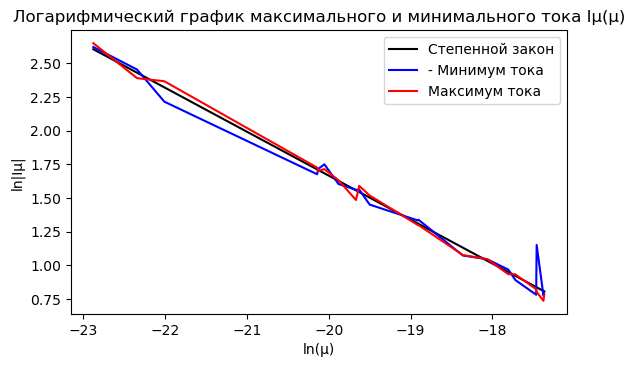

In [17]:
# Define our plot object
fig, ax = plt.subplots()
plt.title(f"Логарифмический график максимального и минимального тока I\u03BC(\u03BC)")
ax.set_ylabel('ln|I\u03BC|')
ax.set_xlabel("ln(\u03BC)")

x = mu_np
y1 = Imn_np
y2 = Imx_np

# Plot logrithm to visually inspect power-law dependence
ax.plot(np.log(x), slope* np.log(x) + intercept, color = "black", label = "Степенной закон")
ax.plot(np.log(x), np.log(np.abs(y1)), color = "blue", label = "- Минимум тока")
ax.plot(np.log(x), np.log(y2), color = "red", label = "Максимум тока")

plt.legend()

ax.set_box_aspect(2.0/3.5)

plt.savefig("loglog_mu_I.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

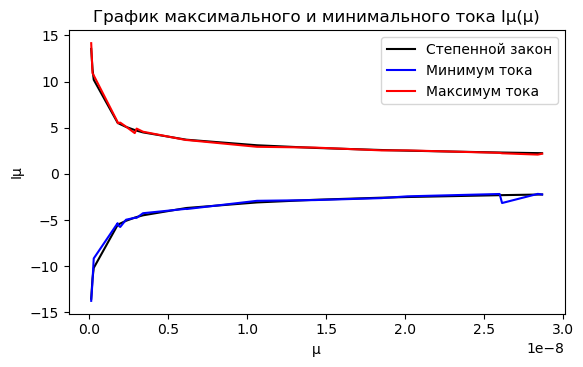

In [18]:
# Define our plot object
fig, ax = plt.subplots()
plt.title(f"График максимального и минимального тока I\u03BC(\u03BC)")
ax.set_ylabel('I\u03BC')
ax.set_xlabel("\u03BC")

x = mu_np
y1 = Imn_np
y2 = Imx_np

ax.plot(x, np.exp(slope* np.log(x) + intercept), color = "black", label = "Степенной закон")
ax.plot(x, -np.exp(slope* np.log(x) + intercept), color = "black")
ax.plot(x, y1, color = "blue", label = "Минимум тока")
ax.plot(x, y2, color = "red", label = "Максимум тока")

plt.legend()
ax.set_box_aspect(2.0/3.5)

plt.savefig("lin_mu_I.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

This model works well. The numbers which I found are as follows:
\begin{equation}
\left|I_\mu\right|_{max} = 0.006295 \, \mu^{-0.338} 
\end{equation}

There is a slight complication, as this doesn't predict what will happen as $\mu$ approaches $0$, since the model goes to infinity as $\mu$ approaches $0$. However, $I_0$ actually has a smaller range than $I_\mu$ for this dataset. So the model breaks down for some small value of $\mu$. This is to be expected, as it is not unusual for emergent behavior.